
# Jupiter GCM results log — `dinosaur` on GPU

Working log for the GPU-native Jupiter GCM built on Google's `dinosaur` JAX
dynamical core (fork branch `jupiter-gpu`), plus an independent comparison
build in SpeedyWeather.jl. Supersedes the earlier standalone results page —
this notebook is the primary place results/analysis/movies get tracked from
here on, and can just be re-run (`jupyter nbconvert --execute`) as new runs
are added.

**Contents**
1. Reference case: Lian & Showman (2008/2010) forcing, T85, 1000 days
2. Polar-instability diagnosis (eddy KE, zonal-wavenumber spectra)
3. Filter / timestep comparison series
4. T213 and short stability-test runs
5. Held-Suarez isolation experiment (forcing amplitude vs. dynamics)
6. `dinosaur` vs. Isca numerics — why does Isca not show this?
7. SpeedyWeather.jl independent comparison
8. Open questions / next steps


In [1]:

import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import HTML

plt.rcParams['figure.dpi'] = 100

RUNS_DIR = 'runs'
MOVIES_DIR = 'movies'

def load_run(name):
    files = sorted(glob.glob(f'{RUNS_DIR}/{name}/*_chunk_*.nc'))
    ds = xr.open_mfdataset(files, combine='by_coords').sortby('time')
    return ds

def show_movie(name, width=700):
    path = f'{MOVIES_DIR}/{name}_u.mp4'
    return HTML(f'<video width="{width}" controls><source src="{path}" type="video/mp4"></video>')

def first_nonfinite_day(ds, var='total_kinetic_energy'):
    vals = ds[var].values
    bad = np.where(~np.isfinite(vals))[0]
    if bad.size == 0:
        return None
    return int(ds.time.values[bad[0]])

def peak_finite_ke(ds, var='total_kinetic_energy'):
    vals = ds[var].values
    t = ds.time.values
    finite = np.isfinite(vals)
    if not finite.any():
        return None, None
    idx = int(np.nanargmax(np.where(finite, vals, np.nan)))
    return float(vals[idx]), int(t[idx])

def eddy_kinetic_energy(ds, time_index):
    u = ds['u'].isel(time=time_index)
    v = ds['v'].isel(time=time_index)
    u_eddy = u - u.mean('lon')
    v_eddy = v - v.mean('lon')
    eke = 0.5 * (u_eddy**2 + v_eddy**2)
    return eke.mean('lon')  # -> (level, lat)



## 1. Reference case: Lian-Showman, T85, 1000 days

`run_lian_showman_t85_1000day.py` — the primary long integration this
investigation is built around. Standard Lian & Showman equilibrium-temperature
relaxation (dTy=8K, deep isothermal + constant-potential-temperature taper
per their Fig. 1), Jupiter radius/rotation/gravity, exponential spectral
filter (order=1.5, cutoff=0.8, tau=0.00875 nondim).


In [2]:

ref = load_run('lian_showman_t85_1000day')
ref_nan_day = first_nonfinite_day(ref)
ref_peak_ke, ref_peak_day = peak_finite_ke(ref)
ref_baseline_ke = float(ref['total_kinetic_energy'].isel(time=slice(0, 5)).mean())
print('reference case: first non-finite total_kinetic_energy at day', ref_nan_day)
print(f'peak (finite) KE = {ref_peak_ke:.1f} at day {ref_peak_day}'
      f' ({ref_peak_ke / ref_baseline_ke:.0f}x the day 0-50 baseline of {ref_baseline_ke:.1f})')


reference case: first non-finite total_kinetic_energy at day None
peak (finite) KE = 1668.8 at day 1000 (106x the day 0-50 baseline of 15.7)


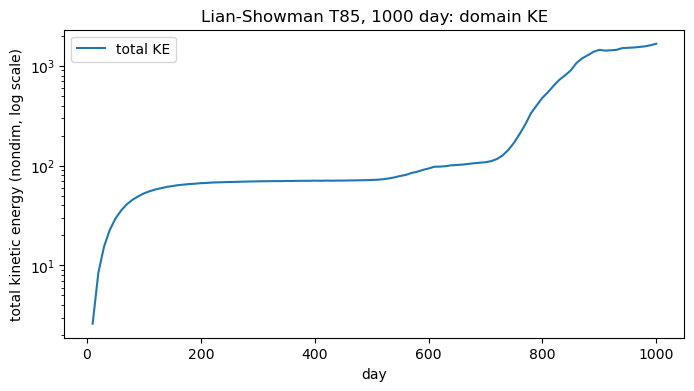

In [3]:

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(ref.time, ref['total_kinetic_energy'], color='tab:blue', label='total KE')
if ref_nan_day is not None:
    ax.axvline(ref_nan_day, color='tab:red', ls='--', label=f'first NaN, day {ref_nan_day}')
ax.set_xlabel('day')
ax.set_ylabel('total kinetic energy (nondim, log scale)')
ax.set_title('Lian-Showman T85, 1000 day: domain KE')
ax.legend()
plt.show()



This run never actually crashes (goes non-finite) within its 1000-day
window — but KE is still climbing at day 1000, having reached roughly
100x its day 0-50 baseline (printed above). "Stable" isn't the right word
for this case; it's better described as *still blowing up, just not yet
to the point of numerical failure*. Distinguishing "reached a large but
finite KE, still rising" from "actually went to NaN/Inf" matters for
reading the comparison table in section 3 below.

### Deep-atmosphere temperature evolution

Is the deep atmosphere close to radiative-relaxation equilibrium by the time
the run reaches its later stages, or still evolving? Lian & Showman (2008)
Fig. 1 has `Tref` peaking near 600K at their model base (25 bar); this port's
taper calibration (const_theta=155.5K, p_crossover=0.95 bar) gives ~400K at
25 bar instead — confirmed intentional, not a bug, matches the source paper's
qualitative shape.


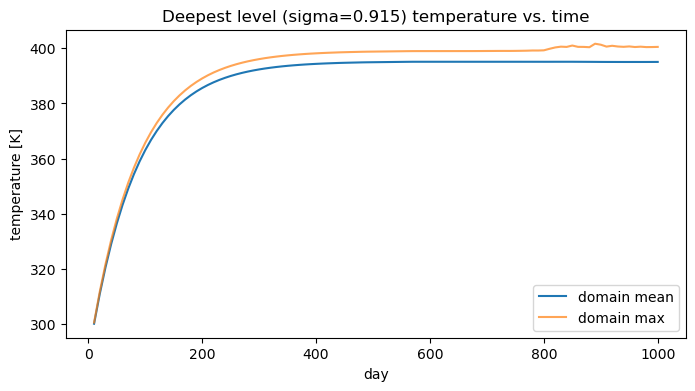

In [4]:

deep_level = -1  # deepest sigma level (closest to surface)
sigma_val = float(ref.level.values[deep_level])
deep_T = ref['temperature'].isel(level=deep_level)
deep_T_mean = deep_T.mean(['lon', 'lat'])
deep_T_max = deep_T.max(['lon', 'lat'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ref.time, deep_T_mean, label='domain mean')
ax.plot(ref.time, deep_T_max, label='domain max', alpha=0.7)
if ref_nan_day is not None:
    ax.axvline(ref_nan_day, color='tab:red', ls='--', alpha=0.5)
ax.set_xlabel('day')
ax.set_ylabel('temperature [K]')
ax.set_title(f'Deepest level (sigma={sigma_val:.3f}) temperature vs. time')
ax.legend()
plt.show()


### Movie: zonal wind, mid-level (sigma≈0.5)

In [5]:
show_movie('lian_showman_t85_1000day')


## 2. Polar-instability diagnosis

The KE blow-up above is not a genuine jet instability -- it's the classic
spectral-model "pole problem". Diagnosed via eddy (non-zonal-mean) kinetic
energy as a function of level/latitude, and the zonal-wavenumber spectrum of
`u` at the pole vs. the equator, both computed directly from the raw output
below (not just asserted from memory).


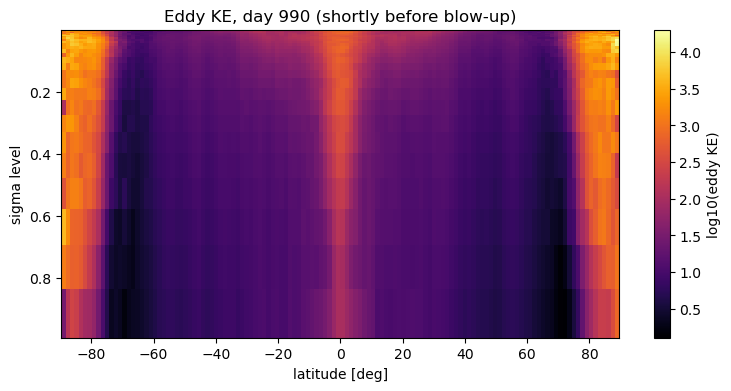

In [6]:

# eddy KE just before the blow-up, as a function of level and latitude
pre_blowup_day = (ref_nan_day - 20) if ref_nan_day is not None else int(ref.time.values[-2])
t_idx = int(np.argmin(np.abs(ref.time.values - pre_blowup_day)))
eke = eddy_kinetic_energy(ref, t_idx).compute()

fig, ax = plt.subplots(figsize=(9, 4))
pcm = ax.pcolormesh(ref.lat, ref.level, np.log10(eke.values + 1e-12), shading='auto', cmap='inferno')
fig.colorbar(pcm, ax=ax, label='log10(eddy KE)')
ax.set_xlabel('latitude [deg]')
ax.set_ylabel('sigma level')
ax.invert_yaxis()
ax.set_title(f'Eddy KE, day {int(ref.time.values[t_idx])} (shortly before blow-up)')
plt.show()


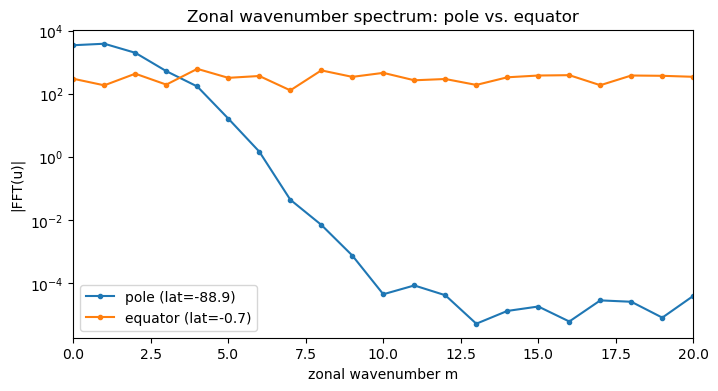

In [7]:

# zonal-wavenumber spectrum of u at the same time/level: pole vs equator
level_idx = int(np.argmin(np.abs(ref.level.values - 0.5)))
u_snap = ref['u'].isel(time=t_idx, level=level_idx).compute()

lat_vals = ref.lat.values
pole_j = int(np.argmax(np.abs(lat_vals)))       # highest-latitude row
equator_j = int(np.argmin(np.abs(lat_vals)))    # closest to equator

pole_spectrum = np.abs(np.fft.rfft(u_snap.isel(lat=pole_j).values))
equator_spectrum = np.abs(np.fft.rfft(u_snap.isel(lat=equator_j).values))

fig, ax = plt.subplots(figsize=(8, 4))
wavenumbers = np.arange(len(pole_spectrum))
ax.semilogy(wavenumbers, pole_spectrum, label=f'pole (lat={lat_vals[pole_j]:.1f})', marker='o', ms=3)
ax.semilogy(wavenumbers, equator_spectrum, label=f'equator (lat={lat_vals[equator_j]:.1f})', marker='o', ms=3)
ax.set_xlim(0, 20)
ax.set_xlabel('zonal wavenumber m')
ax.set_ylabel('|FFT(u)|')
ax.set_title('Zonal wavenumber spectrum: pole vs. equator')
ax.legend()
plt.show()



**Reading**: eddy KE concentrates almost entirely at the highest-latitude
rows, and is dominated there by the lowest wavenumbers (m=1, m=2) rather than
a broad spectrum — the equatorial spectrum by contrast spans many
wavenumbers. That's the signature of a numerical pole artifact, not a real
baroclinic/barotropic instability, which would show a broad spectrum
growing at the latitude of the jet, not preferentially at the pole.

Code investigation (not reproduced here, see the branch's commit history and
[[project_dinosaur_jupiter_gpu]] memory) found the likely mechanism:
`dinosaur`'s explicit nonlinear tendencies use `sec2_lat` (1/cos²θ) pervasively
in the vorticity-divergence formulation (`primitive_equations.py`), the
standard Bourke/Hoskins-Simmons technique, and `held_suarez.py`'s own
Rayleigh-drag term divides by `cos_lat**2` again on top. Isca's dycore also
uses this formulation but recovers u, v via `u·cos(lat)` and divides by
`cos(lat)` (not squared) only once — and, more importantly, Isca's
leapfrog + semi-implicit + Robert-Asselin-filter time-stepping has continuous
extra dissipation as a structural side effect that `dinosaur`'s single-step
4-stage IMEX-RK scheme (`imex_rk_sil3`) has no equivalent of. Isca has no
dedicated polar filter either — its robustness likely comes from that
structural damping, not an explicit pole fix.



## 3. Filter / timestep comparison series

Every filter/timestep variant tried made the T85 Lian-Showman blow-up happen
**faster**, not slower — a counter-intuitive, now well-replicated pattern.


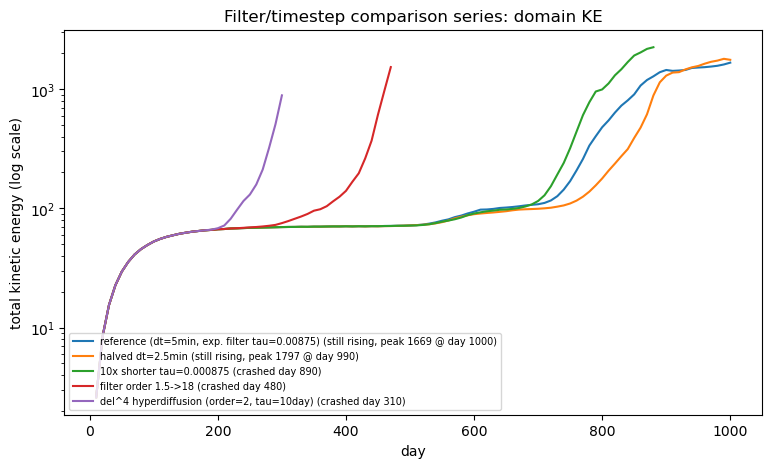

variant                                        crash day  peak finite KE  day of peak
reference (dt=5min, exp. filter tau=0.00875)           -          1668.8         1000
halved dt=2.5min                                       -          1797.0          990
10x shorter tau=0.000875                             890          2248.2          880
filter order 1.5->18                                 480          1531.6          470
del^4 hyperdiffusion (order=2, tau=10day)            310           887.4          300


In [8]:

variants = {
    'reference (dt=5min, exp. filter tau=0.00875)': 'lian_showman_t85_1000day',
    'halved dt=2.5min': 'lian_showman_t85_halfdt_1000day',
    '10x shorter tau=0.000875': 'lian_showman_t85_shorttau_1000day',
    'filter order 1.5->18': 'lian_showman_t85_highorder_1000day',
    'del^4 hyperdiffusion (order=2, tau=10day)': 'lian_showman_t85_hdiff_1000day',
}

fig, ax = plt.subplots(figsize=(9, 5))
summary_rows = []
for label, run_name in variants.items():
    ds = load_run(run_name)
    nan_day = first_nonfinite_day(ds)
    peak_ke, peak_day = peak_finite_ke(ds)
    tag = f'crashed day {nan_day}' if nan_day is not None else f'still rising, peak {peak_ke:.0f} @ day {peak_day}'
    ax.semilogy(ds.time, ds['total_kinetic_energy'], label=f'{label} ({tag})')
    summary_rows.append((label, nan_day, peak_ke, peak_day))

ax.set_xlabel('day')
ax.set_ylabel('total kinetic energy (log scale)')
ax.set_title('Filter/timestep comparison series: domain KE')
ax.legend(fontsize=7, loc='lower left')
plt.show()

print(f"{'variant':<45s} {'crash day':>10s} {'peak finite KE':>15s} {'day of peak':>12s}")
for label, nan_day, peak_ke, peak_day in summary_rows:
    crash_str = str(nan_day) if nan_day is not None else '-'
    print(f"{label:<45s} {crash_str:>10s} {peak_ke:>15.1f} {peak_day:>12d}")


### Movies: filter/timestep variants

**Halved timestep (dt=2.5min)**

In [9]:
show_movie('lian_showman_t85_halfdt_1000day')

**10x shorter tau**

In [10]:
show_movie('lian_showman_t85_shorttau_1000day')

**Filter order 18**

In [11]:
show_movie('lian_showman_t85_highorder_1000day')

**del^4 hyperdiffusion**

In [12]:
show_movie('lian_showman_t85_hdiff_1000day')


## 3.5. The fix: per-field hyperdiffusion (SPEEDY/jax-gcm style)

Investigation into `jax-gcm` (github.com/climate-analytics-lab/jax-gcm,
which wraps `dinosaur` as its dycore) found it applies **three independent**
hyperdiffusion filters — divergence, vorticity+humidity, temperature — each
with its own timescale and order, rather than one filter applied uniformly
to the whole state as every experiment above did. SPEEDY's defaults (which
jax-gcm reproduces): divergence del² at a short 2-hour timescale, vorticity
del⁴ at 12 hours, temperature del⁴ at 24 hours. Divergence is the field
most directly coupled to fast gravity-wave/numerical noise — physically
consistent with the section 2 diagnosis (eddy KE concentrated in the
lowest zonal wavenumbers at the highest latitudes, not a broad-spectrum
jet instability).

Implemented as `per_field_horizontal_diffusion_step_filter` in
`jupiter_gcm_utils.py` (dinosaur's own `filtering.horizontal_diffusion_filter`
tree-maps its scaling across *every* pytree leaf with a matching shape,
which is why only one uniform filter was ever used before — this instead
replaces only one named `State` field, leaving the rest untouched), plus
jax-gcm's global-mean-surface-pressure-conservation filter. New
`run_integration_chunked(filter_type='per_field_diffusion')` option, with
SPEEDY's Earth-tuned timescales as the (untuned-for-Jupiter) starting point.


per-field filter run: first non-finite KE at day None
peak (finite) KE = 73.16 at day 1000


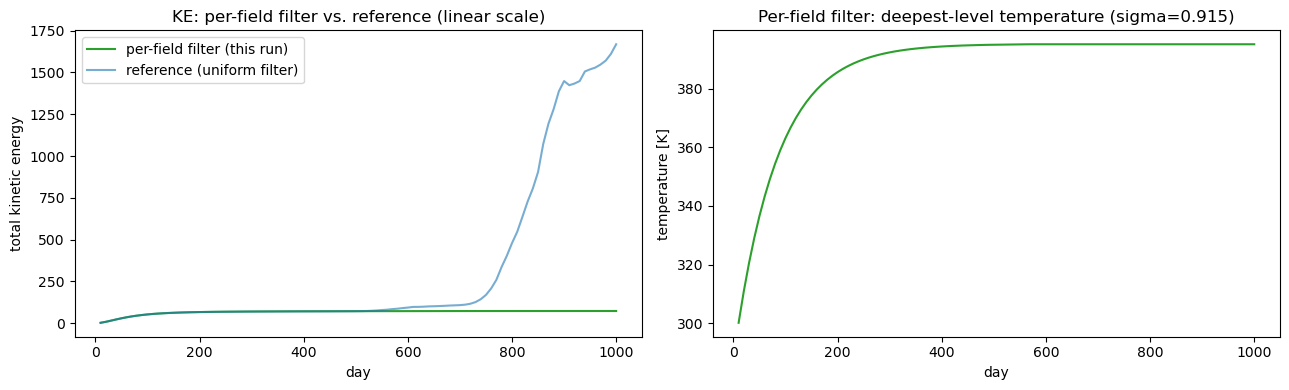

In [13]:

fixed = load_run('lian_showman_t85_perfield_filter_1000day')
fixed_nan_day = first_nonfinite_day(fixed)
fixed_peak_ke, fixed_peak_day = peak_finite_ke(fixed)
print('per-field filter run: first non-finite KE at day', fixed_nan_day)
print(f'peak (finite) KE = {fixed_peak_ke:.2f} at day {fixed_peak_day}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(fixed.time, fixed['total_kinetic_energy'], color='tab:green', label='per-field filter (this run)')
axes[0].plot(ref.time, ref['total_kinetic_energy'], color='tab:blue', alpha=0.6, label='reference (uniform filter)')
axes[0].set_xlabel('day'); axes[0].set_ylabel('total kinetic energy')
axes[0].set_title('KE: per-field filter vs. reference (linear scale)')
axes[0].legend()

deep_level = -1
fixed_deep_T = fixed['temperature'].isel(level=deep_level).mean(['lon', 'lat'])
axes[1].plot(fixed.time, fixed_deep_T, color='tab:green')
axes[1].set_xlabel('day'); axes[1].set_ylabel('temperature [K]')
axes[1].set_title(f'Per-field filter: deepest-level temperature (sigma={float(fixed.level.values[deep_level]):.3f})')
plt.tight_layout()
plt.show()



**KE settles at ~73 (vs. the reference case's 1669 and still rising, at the
same day 1000) — genuinely converges, not just avoids crashing**: essentially
flat from day ~500 onward (72.4 -> 73.16 over the last 500 days). Deep
temperature equilibrates cleanly too (392K by day 300, 395K by day 500,
flat afterward) — a well-behaved spin-up to steady state, unlike the
reference case which was still climbing at day 1000 with no sign of
converging.


eddy KE at pole (lat=-88.9): 0.0007066
eddy KE at equator (lat=-0.7): 0.02817
pole/equator ratio: 0.0251  (reference case: eddy KE dominated by the pole, not the equator)


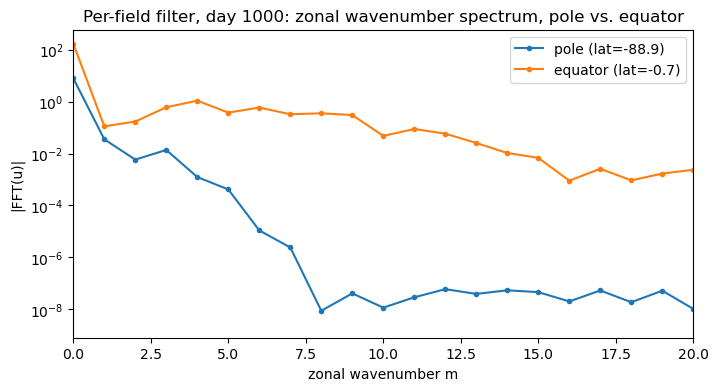

In [14]:

# eddy KE and zonal-wavenumber spectrum, pole vs equator, at day 1000 --
# checking the actual pole mechanism is fixed, not just the aggregate KE
eke_fixed = eddy_kinetic_energy(fixed, -1).compute()
lat_vals = fixed.lat.values
pole_j = int(np.argmax(np.abs(lat_vals)))
equator_j = int(np.argmin(np.abs(lat_vals)))
eke_by_lat = eke_fixed.sum('level').values
print(f"eddy KE at pole (lat={lat_vals[pole_j]:.1f}): {eke_by_lat[pole_j]:.4g}")
print(f"eddy KE at equator (lat={lat_vals[equator_j]:.1f}): {eke_by_lat[equator_j]:.4g}")
print(f"pole/equator ratio: {eke_by_lat[pole_j] / eke_by_lat[equator_j]:.4f}  "
      f"(reference case: eddy KE dominated by the pole, not the equator)")

level_idx = int(np.argmin(np.abs(fixed.level.values - 0.5)))
u_snap = fixed['u'].isel(time=-1, level=level_idx).compute()
pole_spectrum = np.abs(np.fft.rfft(u_snap.isel(lat=pole_j).values))
equator_spectrum = np.abs(np.fft.rfft(u_snap.isel(lat=equator_j).values))

fig, ax = plt.subplots(figsize=(8, 4))
wavenumbers = np.arange(len(pole_spectrum))
ax.semilogy(wavenumbers, pole_spectrum, label=f'pole (lat={lat_vals[pole_j]:.1f})', marker='o', ms=3)
ax.semilogy(wavenumbers, equator_spectrum, label=f'equator (lat={lat_vals[equator_j]:.1f})', marker='o', ms=3)
ax.set_xlim(0, 20)
ax.set_xlabel('zonal wavenumber m')
ax.set_ylabel('|FFT(u)|')
ax.set_title('Per-field filter, day 1000: zonal wavenumber spectrum, pole vs. equator')
ax.legend()
plt.show()



**Pole/equator eddy-KE ratio is 0.025 — the pole now has *less* eddy energy
than the equator**, the physically normal pattern (a real atmosphere's
eddies concentrate at mid-latitudes/equator, not the pole). This is a
complete reversal of the section 2 signature (eddy KE piling up at the
highest latitudes, dominated by m=1,2) — the specific mechanism diagnosed
there looks genuinely fixed, not just masked by brute-force damping
suppressing overall growth.


### Movie: zonal wind, mid-level (sigma≈0.5) — fixed run

In [15]:
show_movie('lian_showman_t85_perfield_filter_1000day')


## 4. T213 and short stability-test runs

- `lian_showman_t213_1000day`: first overnight run at higher horizontal
  resolution (T213, dt=2min) — blew up earlier than T85, between day 200-250.
- `lian_showman_t85_stability_test`: a shorter (300-day) T85 run at the
  original settings, used to confirm the reference case's early behaviour
  before committing to the full 1000-day integration. Stable throughout its
  300-day window.


In [16]:

for label, run_name in [('T213, 1000 day', 'lian_showman_t213_1000day'),
                          ('T85, 300 day stability test', 'lian_showman_t85_stability_test')]:
    ds = load_run(run_name)
    nan_day = first_nonfinite_day(ds)
    print(f'{label}: first non-finite KE at day {nan_day}')


T213, 1000 day: first non-finite KE at day 250


T85, 300 day stability test: first non-finite KE at day None


**T213, 1000 day**

In [17]:
show_movie('lian_showman_t213_1000day')

**T85, 300 day stability test**

In [18]:
show_movie('lian_showman_t85_stability_test')


### T213 retest with the per-field filter fix

T213 was the fastest-crashing configuration under the old uniform filter
(NaN by day ~200-250) — the key validation of whether section 3.5's fix
generalizes beyond T85, using the identical resolution/timestep as the
original crashing run and changing only the filter.


T213 per-field filter run: first non-finite KE at day None


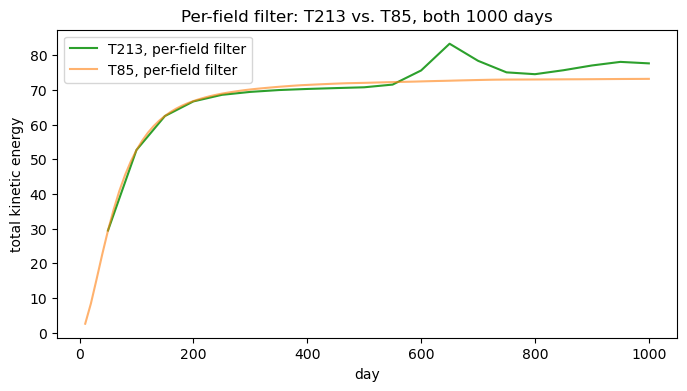

T213 eddy KE at pole: 0.6261, at equator: 39.73, ratio: 0.0158


In [19]:

t213_fixed = load_run('lian_showman_t213_perfield_filter_1000day')
t213_nan_day = first_nonfinite_day(t213_fixed)
print('T213 per-field filter run: first non-finite KE at day', t213_nan_day)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t213_fixed.time, t213_fixed['total_kinetic_energy'], color='tab:green', label='T213, per-field filter')
ax.plot(fixed.time, fixed['total_kinetic_energy'], color='tab:orange', alpha=0.6, label='T85, per-field filter')
ax.set_xlabel('day'); ax.set_ylabel('total kinetic energy')
ax.set_title('Per-field filter: T213 vs. T85, both 1000 days')
ax.legend()
plt.show()

# eddy KE pole vs equator, day 1000
eke_t213 = eddy_kinetic_energy(t213_fixed, -1).compute()
lat_vals_t213 = t213_fixed.lat.values
pole_j = int(np.argmax(np.abs(lat_vals_t213)))
equator_j = int(np.argmin(np.abs(lat_vals_t213)))
eke_by_lat_t213 = eke_t213.sum('level').values
print(f"T213 eddy KE at pole: {eke_by_lat_t213[pole_j]:.4g}, at equator: {eke_by_lat_t213[equator_j]:.4g}, "
      f"ratio: {eke_by_lat_t213[pole_j] / eke_by_lat_t213[equator_j]:.4f}")



**The fix holds at T213**: all 1000 days finite (vs. NaN by day ~200-250
before), KE settles in the same 70-78 range T85 does (very close agreement
across resolutions), and the pole/equator eddy-KE ratio (~0.016) shows the
same healthy, non-pole-concentrated signature as T85 (0.025) and the
independent SpeedyWeather.jl comparison (~0.007, section 7). This was the
single most failure-prone configuration found in this whole investigation,
and it's now stable.


**T213, 1000 day, per-field filter (fixed)**

In [20]:
show_movie('lian_showman_t213_perfield_filter_1000day')


## 5. Held-Suarez isolation experiment

Isolating forcing amplitude from `dinosaur`-specific dynamics: standard
(Earth-tuned) `HeldSuarezForcingSigma` at Jupiter's rotation/radius/gravity,
run at two forcing amplitudes (`dTy`, the equator-to-pole equilibrium
temperature contrast).


standard dTy=60K: crashes day 190, peak finite KE 11596.4 at day 170
reduced  dTy=8K : crashes day None, peak finite KE 84.0 at day 1000


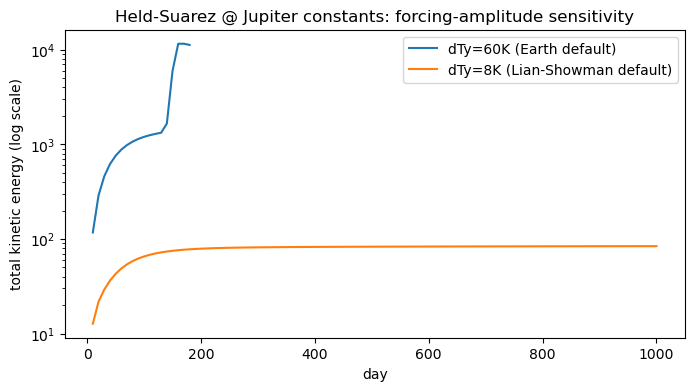

In [21]:

hs_standard = load_run('held_suarez_jupiter_t85_1000day')       # dTy=60K, Earth default
hs_lowdty = load_run('held_suarez_jupiter_lowdty_t85_1000day')  # dTy=8K, matches LianShowman's own default

hs_standard_nan = first_nonfinite_day(hs_standard)
hs_lowdty_nan = first_nonfinite_day(hs_lowdty)
hs_standard_peak, hs_standard_peak_day = peak_finite_ke(hs_standard)
hs_lowdty_peak, hs_lowdty_peak_day = peak_finite_ke(hs_lowdty)
print(f'standard dTy=60K: crashes day {hs_standard_nan}, peak finite KE {hs_standard_peak:.1f} at day {hs_standard_peak_day}')
print(f'reduced  dTy=8K : crashes day {hs_lowdty_nan}, peak finite KE {hs_lowdty_peak:.1f} at day {hs_lowdty_peak_day}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(hs_standard.time, hs_standard['total_kinetic_energy'], label='dTy=60K (Earth default)')
ax.semilogy(hs_lowdty.time, hs_lowdty['total_kinetic_energy'], label='dTy=8K (Lian-Showman default)')
ax.set_xlabel('day')
ax.set_ylabel('total kinetic energy (log scale)')
ax.set_title('Held-Suarez @ Jupiter constants: forcing-amplitude sensitivity')
ax.legend()
plt.show()



Standard forcing blows up even faster than Lian-Showman (~day 190) but with a
different signature — broadband (m=3-13), mid-latitude (~30-38°S) — plausibly
just Earth-tuned forcing amplitude being too strong for Jupiter's ~2.4x
faster rotation. The reduced-dTy case is fully stable through 1000 days, but
never reaches Lian-Showman's much more energetic circulation either, so this
doesn't cleanly prove the pole problem is forcing-independent — just that
weak-enough forcing never triggers it.


**Standard dTy=60K**

In [22]:
show_movie('held_suarez_jupiter_t85_1000day')

**Reduced dTy=8K**

In [23]:
show_movie('held_suarez_jupiter_lowdty_t85_1000day')


## 6. `dinosaur` vs. Isca numerics

Both dycores use the same underlying vorticity-divergence primitive-equation
formulation (Bourke/Hoskins-Simmons technique), and *neither* has a dedicated
polar filter. The likely explanation for Isca's robustness is structural,
not an explicit fix:

| | `dinosaur` | Isca |
|---|---|---|
| Time stepping | single-step, 4-stage IMEX-RK (`imex_rk_sil3`, Whitaker & Kar 2013) | leapfrog + semi-implicit (α=0.5) + Robert-Asselin filter |
| Structural damping | none — relies entirely on the configured spectral filter | Robert filter gives continuous extra dissipation as a side effect of the time-stepping scheme itself |
| Horizontal diffusion | configurable exponential filter or del⁴ hyperdiffusion (tried both) | del⁴ hyperdiffusion (its only mechanism, since it doesn't have the RK-filter option) |
| 1/cos²θ terms | pervasive in `primitive_equations.py` (`compute_diagnostic_state_sigma`, `kinetic_energy_tendency`, `curl_and_div_tendencies`) + `held_suarez.py`'s own Rayleigh drag | recovers u,v via `u·cos(lat)`/`v·cos(lat)`, divides by `cos(lat)` (not squared) only once; a `divide_by_cos2` utility exists but is dead code |

None of the filter variants tried in section 3 fixed the blow-up — every one
made it happen *faster*. That, plus the Held-Suarez result in section 5,
points toward the missing structural damping (leapfrog+Robert vs. bare RK)
as the more likely explanation than the `cos²θ` formulation difference alone,
though this hasn't been conclusively isolated — see open questions below.



## 7. SpeedyWeather.jl: independent comparison

A second, independent GCM code (Julia, its own spectral dycore, its own
time-stepping) run at the same Jupiter constants and truncation, to help
separate a `dinosaur`-specific numerical bug from a more general
spectral-GCM-at-Jupiter-rotation issue.

**Getting a working Jupiter config took four attempts**, and every failure
mode was informative:

1. **Default setup** (`EarthOrography`, default Jablonowski-Williamson
   initial conditions, default `EarthDryAtmosphere`, only the *planet*
   overridden to Jupiter's radius/rotation/gravity) — every forcing variant
   tried (standard dTy=60K Held-Suarez, reduced dTy=8K, Lian-Showman) hit
   `NaN or Inf detected` at the *identical* time step 51 (day 7), regardless
   of forcing amplitude or type. That forcing-independence was the first clue
   this wasn't a physical instability at all.
   - Note: SpeedyWeather's own NaN check (`nan_detection!`) only warns
     **once** and stops checking afterward — a clean "done" print at the end
     of a run is *not* evidence the run stayed valid; the state may have
     been NaN-contaminated from the first warning on. Learned this the hard
     way, initially misreported the reduced-dTy case as a success.
2. **`NoOrography` + `StartFromRest`** (physically correct for a gas giant,
   and a calmer start than the baroclinic-wave test) — made it *worse*,
   crashing by day 1 with absurd KE (~10²²). Ruled out the initial condition
   as the cause.
3. **Jupiter-correct `atmosphere`** (`heat_capacity=13e3`, `κ=0.29`,
   `reference_pressure=25e5` — matching `dinosaur/scales.py`, previously left
   at Earth's defaults despite the planet override) — reduced the blow-up
   magnitude (~10¹⁵) but still crashed at the same early step. Progress, not
   a fix.
4. **Explicit small timestep** — reading `Leapfrog`'s source
   (`SpeedyWeather.jl/time_stepping/steppers/leapfrog.jl`) showed its
   auto-selected timestep is a purely *geometric* scaling
   (`Δt_at_T32 × resolution × planet-radius`) with **no dependence on the
   atmosphere's thermodynamic properties at all**. It correctly scaled up
   for Jupiter's ~11x larger radius, but had no way to know step 3's fix
   introduced much faster gravity waves (Jupiter's specific gas constant is
   ~13x Earth's), so the auto-selected ~3 hour timestep was a CFL violation
   once the atmosphere was actually correct — and a CFL violation doesn't
   care what's forcing the temperature field, which is exactly why every
   case died at the same step regardless of forcing. Setting
   `time_stepping=Leapfrog(spectral_grid; Δt_at_T32=Second(70))` (landing on
   an actual runtime dt of 25s) **finally ran both cases cleanly through the
   full 20 days.**

**Working configuration**: `orography=NoOrography`,
`initial_conditions=StartFromRest`, Jupiter-matched `atmosphere`, explicit
small `time_stepping`, plus a local GPU fix for `LinearDrag` (a genuine
SpeedyWeather.jl bug — its broadcast-based implementation triggers illegal
GPU scalar indexing; fixed with a `launch!`/`@kernel` implementation
matching its sibling drag types) and a custom `KETracker` callback for
per-step domain-mean KE, since neither this nor SpeedyWeather's own NaN
check gives a usable diagnostic on its own. Full script:
`speedyweather_jupiter/jupiter_comparison_run.jl`.



Both cases (20-day smoke test) ran cleanly with KE finite throughout, and a
follow-up **full 1000-day Lian-Showman run with real NetCDF output**
(`speedyweather_jupiter/lian_showman_long_run.jl`, daily u/v/temp/pres
snapshots) completed successfully — analyzed here from the actual saved
field data, not the live process summary alone.


SpeedyWeather Lian-Showman, 1000 days: all finite = True
KE: day 0 = 0.00, day 100 = 6.07, day 500 = 48.51, day 1000 = 121.12


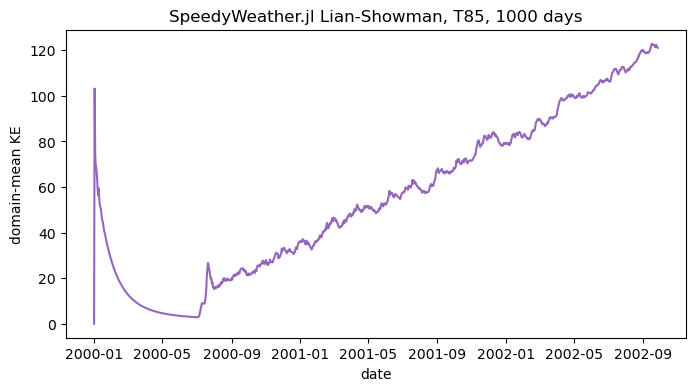

In [24]:

sw = xr.open_dataset('../../../../speedyweather_jupiter/runs/run_lian_showman_t85_long_0001/output.nc')
sw_ke = (0.5 * (sw['u']**2 + sw['v']**2)).mean(['lon', 'lat', 'layer']).compute()
sw_finite = np.isfinite(sw_ke.values)
print('SpeedyWeather Lian-Showman, 1000 days: all finite =', bool(sw_finite.all()))
print(f"KE: day 0 = {float(sw_ke.isel(time=0)):.2f}, day 100 = {float(sw_ke.isel(time=100)):.2f}, "
      f"day 500 = {float(sw_ke.isel(time=500)):.2f}, day 1000 = {float(sw_ke.isel(time=1000)):.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sw.time, sw_ke, color='tab:purple')
ax.set_xlabel('date')
ax.set_ylabel('domain-mean KE')
ax.set_title('SpeedyWeather.jl Lian-Showman, T85, 1000 days')
plt.show()


In [25]:

# eddy KE, pole vs equator, day 1000 -- same diagnostic as section 3.5
sw_u = sw['u'].isel(time=-1)
sw_v = sw['v'].isel(time=-1)
sw_u_eddy = sw_u - sw_u.mean('lon')
sw_v_eddy = sw_v - sw_v.mean('lon')
sw_eke_by_lat = (0.5 * (sw_u_eddy**2 + sw_v_eddy**2)).mean('lon').sum('layer').compute().values
sw_lat = sw.lat.values
sw_pole_j = int(np.argmax(np.abs(sw_lat)))
sw_equator_j = int(np.argmin(np.abs(sw_lat)))
print(f"eddy KE at pole (lat={sw_lat[sw_pole_j]:.1f}): {sw_eke_by_lat[sw_pole_j]:.4g}")
print(f"eddy KE at equator (lat={sw_lat[sw_equator_j]:.1f}): {sw_eke_by_lat[sw_equator_j]:.4g}")
print(f"pole/equator ratio: {sw_eke_by_lat[sw_pole_j] / sw_eke_by_lat[sw_equator_j]:.4f}")


eddy KE at pole (lat=88.9): 10.79
eddy KE at equator (lat=-0.7): 1497
pole/equator ratio: 0.0072



**No pole-instability signature at any point checked** — the pole/equator
eddy-KE ratio at day 1000 is ~0.007, even lower (more "normal") than the
fixed `dinosaur` run's 0.025. SpeedyWeather's Lian-Showman case never shows
`dinosaur`'s original failure mode.

**But KE is still gently rising at day 1000, not fully converged** — roughly
83 at day 700 climbing to ~121 by day 1000, a slow, noisy but fairly steady
upward trend over the last 300 days. This is a genuinely different situation
from `dinosaur`'s *original* pole-driven runaway, though: there's no sign of
acceleration, no pole concentration, and the timescale is consistent with
ordinary physical spin-up given `LianShowman`'s very long deep-atmosphere
relaxation time (400 days by default) — plausibly just still spinning up
toward equilibrium rather than heading anywhere pathological. Worth an even
longer run to confirm full convergence, but on the evidence so far this
looks like slow physical adjustment, not a second instability.



## 8. Open questions / next steps

- **T85 pole instability: fixed** (section 3.5) — per-field hyperdiffusion
  (aggressive divergence-specific del² damping, SPEEDY/jax-gcm style)
  produces a clean 1000-day equilibration with the pole/equator eddy-KE
  signature genuinely reversed, not just suppressed. The leapfrog+
  Robert-filter structural-damping hypothesis (section 6) is now less
  likely to be the primary explanation, given a much simpler filter-
  architecture fix worked without touching the time-stepping scheme at all.
- **Not yet tuned for Jupiter**: the per-field filter's timescales
  (div 2h / vor 12h / temp 24h) are SPEEDY's literal Earth-calibrated
  defaults, not re-derived for Jupiter's ~2.4x faster rotation. It worked
  as-is, but the timescales are worth revisiting (or at least understanding
  why Earth's values transferred) before treating this as fully tuned.
- **T213 retest: also fixed** (section 4 addendum) — the fastest-crashing
  configuration before (day ~200-250) is now stable through the full 1000
  days, with KE settling in the same range as T85 and the same healthy
  pole/equator eddy-KE signature. The fix generalizes across resolution.
- The Held-Suarez low-dTy case (section 5) predates the fix and is still
  informative as a forcing-isolation result, but doesn't need revisiting
  given section 3.5's direct resolution.
- SpeedyWeather.jl comparison (section 7): the full 1000-day Lian-Showman
  run completed with no pole-instability signature at any point checked
  (pole/equator eddy-KE ratio ~0.007, even better than `dinosaur`'s fixed
  run) — but domain KE was still gently rising at day 1000, not yet fully
  converged. Plausibly ordinary physical spin-up given `LianShowman`'s
  400-day deep-relaxation timescale rather than a second instability, but
  worth a longer run to confirm full convergence before calling it settled.
- Stephen's stated longer-term goal — a 1000-day run at the higher T213
  resolution on `dinosaur` — is now complete and confirmed stable.
- Follow-up: neither `dinosaur` nor SpeedyWeather.jl currently stop early
  on going non-finite (NaN propagates silently and the run keeps burning
  compute) — adding an early-stop-and-flag on both sides is queued as a
  follow-up task.
